In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
customers = pd.read_csv ('/mnt/HC_Volume_18315164/home-jupyter/jupyter-ekaterina--cky8935/olist_customers_dataset.csv')
order_items = pd.read_csv ('~/olist_order_items_dataset.csv')
orders = pd.read_csv ('~/olist_orders_dataset.csv')

In [26]:
customers.head ()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [27]:
customers.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [28]:
order_items.head ()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [29]:
order_items.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [30]:
orders.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [31]:
orders.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [4]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

In [5]:
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])

In [7]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [8]:
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [38]:
orders.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [39]:
orders.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [9]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

In [10]:
data = orders_delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

In [82]:
data.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [11]:
data['order_period_day'] = data['order_purchase_timestamp'].dt.to_period('D')
data['order_period'] = data['order_purchase_timestamp'].dt.to_period('M')

In [12]:
data['cohort'] = data.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
data['cohort_day'] = data.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [13]:
data['period_number_month'] = np.floor((data.order_period_day - data.cohort_day).apply(attrgetter('n'))/30)

In [41]:
data.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_period_day,cohort,cohort_day,period_number_month,order_period
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,2017-09,2017-09-04,0.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,2018-07-24,2018-07,2018-07-24,0.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,2018-08,2018-08-08,0.0,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,2017-11-18,2017-11,2017-11-18,0.0,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,2018-02,2018-02-13,0.0,2018-02


In [16]:
df_cohort = data.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [89]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1


In [17]:
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [15]:
cohort_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN
2017-03,2503.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,6.0,6.0,...,4.0,4.0,3.0,7.0,2.0,3.0,2.0,NaN,NaN,NaN
2017-04,2256.0,8.0,6.0,1.0,6.0,8.0,6.0,10.0,5.0,6.0,...,3.0,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN
2017-05,3451.0,14.0,14.0,8.0,13.0,11.0,11.0,4.0,10.0,9.0,...,11.0,6.0,3.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN
2017-06,3037.0,13.0,15.0,11.0,5.0,16.0,9.0,6.0,4.0,10.0,...,9.0,3.0,9.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
cohort_size = cohort_pivot.iloc[:, 0]

In [19]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [18]:
retention_matrix.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN


In [20]:
average_retention_first_month = retention_matrix[1].median()
print(f'Медианный retention за первый месяц: {average_retention_first_month:.4f}')

Медианный retention за первый месяц: 0.0035


In [21]:
max_retention_third_month = retention_matrix[3].idxmax()
print(f'Когорта с самым высоким retention на третий месяц: {max_retention_third_month}')

Когорта с самым высоким retention на третий месяц: 2017-01


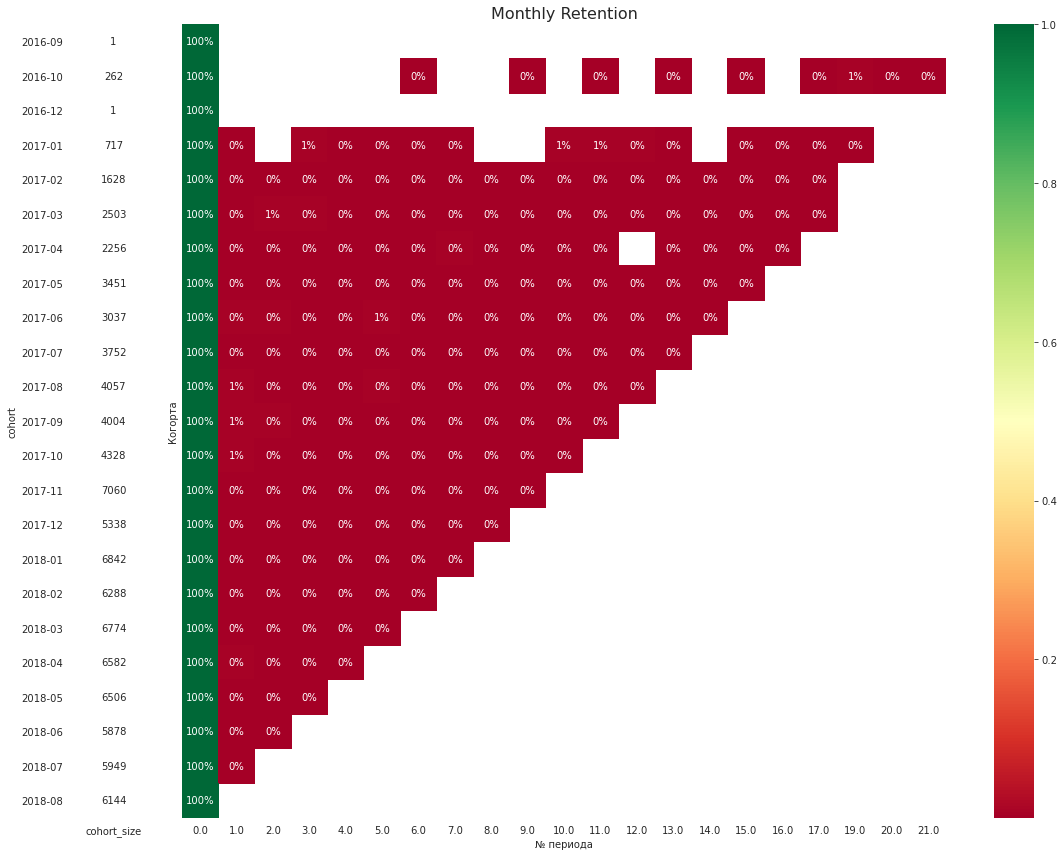

In [21]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [27]:
df_cohort.n_customers.median ()

4057.0

In [5]:
print(f'Метрика: Общий объем продаж (Gross Merchandise Volume, GMV)')

Метрика: Общий объем продаж (Gross Merchandise Volume, GMV)


In [30]:
orders_delivered.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [14]:
total_revenue = data.merge (order_items[['order_id', 'price']], on='order_id', how='left')
total_revenue.head ()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_period_day,order_period,cohort,cohort_day,period_number_month,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,2017-10,2017-09,2017-09-04,0.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,2018-07-24,2018-07,2018-07,2018-07-24,0.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,2018-08,2018-08,2018-08-08,0.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,2017-11-18,2017-11,2017-11,2017-11-18,0.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,2018-02,2018-02,2018-02-13,0.0,19.90


In [66]:
monthly_revenue = total_revenue.groupby('order_period')['price'].sum().reset_index()
monthly_revenue['order_period'] = monthly_revenue['order_period'].astype(str)
monthly_revenue.columns = ['order_period', 'GMV']

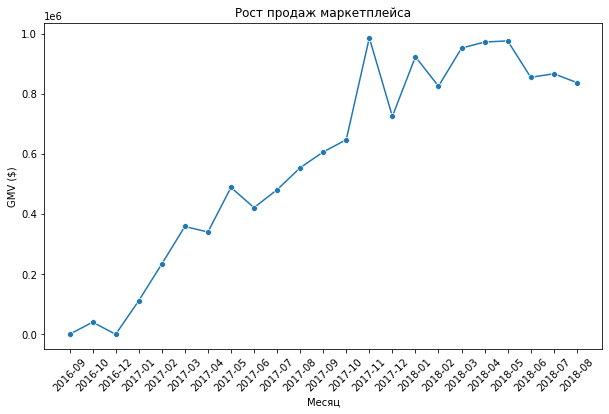

In [67]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='order_period', y='GMV', marker='o')
plt.title('Рост продаж маркетплейса')
plt.xlabel('Месяц')
plt.ylabel('GMV ($)')
plt.xticks(rotation=45)

plt.show()

In [9]:
print(f'Метрика: Количество платящих клиентов (Paying Users)')

Метрика: Количество платящих клиентов (Paying Users)


In [46]:
paying_users = total_revenue.groupby(total_revenue['order_period']).customer_unique_id.nunique().reset_index()
paying_users['order_period'] = paying_users['order_period'].astype(str)
paying_users.columns = ['order_period', 'paying_users']

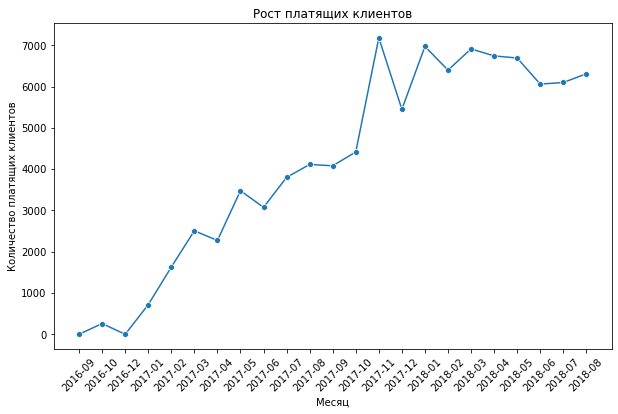

In [47]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=paying_users, x='order_period', y='paying_users', marker='o')
plt.title('Рост платящих клиентов')
plt.xlabel('Месяц')
plt.ylabel('Количество платящих клиентов')
plt.xticks(rotation=45)

plt.show()

In [10]:
print(f'Метрика: Конверсия в первую покупку (Conversion to Paying User)')


Метрика: Конверсия в первую покупку (Conversion to Paying User)


In [54]:
first_order_month = total_revenue.groupby('customer_unique_id')['order_period'].min().to_dict()

In [57]:
total_revenue['is_first_order'] = total_revenue.apply(lambda row: row['order_period'] == first_order_month[row['customer_unique_id']],axis=1)

In [58]:
monthly_data = total_revenue.groupby('order_period').agg({'customer_unique_id': ['nunique', 'count'],'is_first_order': 'sum'}).round(2)

In [59]:
monthly_data.columns = ['total_customers', 'total_orders', 'new_customers']
monthly_data = monthly_data.reset_index()

In [60]:
monthly_data['CAR'] = (monthly_data['new_customers'] / monthly_data['total_customers']) * 100

In [62]:
monthly_data['CAR'] = monthly_data['CAR'].round(2)
monthly_data['order_period'] = monthly_data['order_period'].astype(str)

In [63]:
print(monthly_data[['order_period', 'total_customers', 'new_customers', 'CAR']])

   order_period  total_customers  new_customers     CAR
0       2016-09                1              3  300.00
1       2016-10              262            313  119.47
2       2016-12                1              1  100.00
3       2017-01              718            912  127.02
4       2017-02             1630           1856  113.87
5       2017-03             2508           2892  115.31
6       2017-04             2274           2546  111.96
7       2017-05             3479           3972  114.17
8       2017-06             3076           3441  111.87
9       2017-07             3802           4345  114.28
10      2017-08             4114           4723  114.80
11      2017-09             4083           4644  113.74
12      2017-10             4417           5090  115.24
13      2017-11             7183           8320  115.83
14      2017-12             5450           6044  110.90
15      2018-01             6974           7889  113.12
16      2018-02             6400           7363 

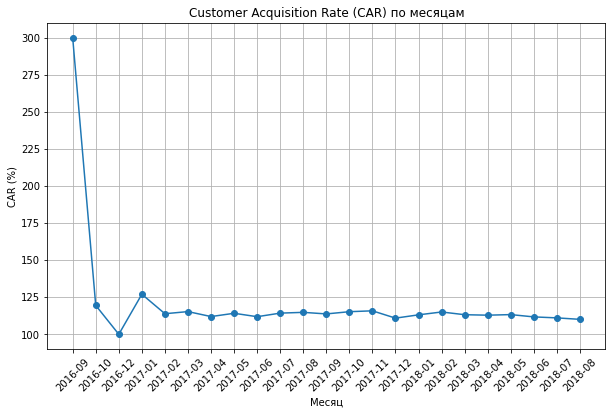

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_data['order_period'], monthly_data['CAR'], marker='o')
plt.title('Customer Acquisition Rate (CAR) по месяцам')
plt.xlabel('Месяц')
plt.ylabel('CAR (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [11]:
print(f'Метрика: Коэффициент удержания (Retention Rate)')


Метрика: Коэффициент удержания (Retention Rate)


In [65]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN
2017-03,1.0,0.002797,0.005194,0.004395,0.001199,0.000799,0.003596,0.001598,0.002397,0.002397,...,0.001598,0.001598,0.001199,0.002797,0.000799,0.001199,0.000799,NaN,NaN,NaN
2017-04,1.0,0.003546,0.002660,0.000443,0.002660,0.003546,0.002660,0.004433,0.002216,0.002660,...,0.001330,NaN,0.000887,0.000887,0.000887,0.000887,NaN,NaN,NaN,NaN
2017-05,1.0,0.004057,0.004057,0.002318,0.003767,0.003187,0.003187,0.001159,0.002898,0.002608,...,0.003187,0.001739,0.000869,0.002028,0.001159,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004281,0.004939,0.003622,0.001646,0.005268,0.002963,0.001976,0.001317,0.003293,...,0.002963,0.000988,0.002963,0.001317,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(f'Метрика: ARPPU')

Метрика: ARPPU


In [74]:
monthly_revenue = total_revenue.groupby('order_period').agg(total_revenue=('price', 'sum'),paying_users=('customer_unique_id', 'nunique')).reset_index()

monthly_revenue['ARRPU'] = monthly_revenue['total_revenue'] / monthly_revenue['paying_users']
monthly_revenue['order_period'] = monthly_revenue['order_period'].astype(str)

monthly_revenue[['order_period', 'total_revenue', 'paying_users', 'ARRPU']]

,order_period,total_revenue,paying_users,ARRPU
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


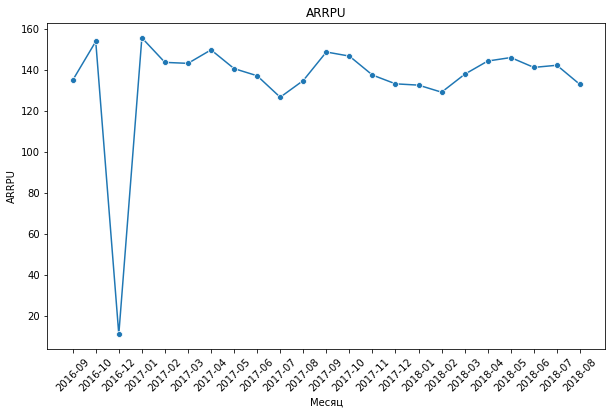

In [75]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='order_period', y='ARRPU', marker='o')
plt.title('ARRPU')
plt.xlabel('Месяц')
plt.ylabel('ARRPU')
plt.xticks(rotation=45)

plt.show()

In [13]:
print(f'Гипотеза 1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. ')


Гипотеза 1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. 


In [26]:
orders['order_period'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [46]:
canceled_orders = orders[(orders.order_period >= '2017-06') & (orders.order_status.isin(['canceled', 'unavailable']))].order_id.nunique()
print(f'Impact гипотезы 1: Количество отмененных заказов: {canceled_orders}')

Impact гипотезы 1: Количество отмененных заказов: 974


In [43]:
print(f'ICE_hypothesis_1 = {5*8*6}')

ICE_hypothesis_1 = 240


In [14]:
print(f'Гипотеза 2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.')

Гипотеза 2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.


In [30]:
orders['order_delivery_day'] = orders['order_delivered_customer_date'].dt.to_period('D')
orders['order_estimated_day'] = orders['order_estimated_delivery_date'].dt.to_period('D')

In [47]:
delayed_orders = orders[(orders.order_period >= '2017-06') & (orders.order_delivery_day > orders.order_estimated_day) & (orders.order_status.isin(['delivered']))].order_id.nunique()
print(f'Количество задержанных заказов: {delayed_orders}')

Количество задержанных заказов: 6087


In [41]:
print(f'Impact гипотезы 2:Возможное количество повторных заказов: {delayed_orders*0.0035}')

Impact гипотезы 2:Возможное количество повторных заказов: 21.3045


In [44]:
print(f'ICE_hypothesis_2 = {1*10*4}')

ICE_hypothesis_2 = 40


In [15]:
print(f'Гипотеза 3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счётповторных заказов тех, кто раньше не делал повторный заказ.')

Гипотеза 3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счётповторных заказов тех, кто раньше не делал повторный заказ.


In [35]:
customer_order_counts = data[(data.order_period >= '2017-06')].groupby('customer_unique_id').order_id.nunique().reset_index()
unique_order_customers_count = (customer_order_counts == 1).order_id.sum()

In [38]:
print(f'Количество задержанных заказов: {unique_order_customers_count}')

Количество задержанных заказов: 80558


In [42]:
print(f'Impact гипотезы 3:Возможное количество повторных заказов: {unique_order_customers_count*0.0035}')

Impact гипотезы 3:Возможное количество повторных заказов: 281.95300000000003


In [45]:
print(f'ICE_hypothesis_3 = {3*5*9}')

ICE_hypothesis_3 = 135


In [16]:
print(f'При сравнении по фреймворку ICE из трех гипотез выигрывает гипотеза 1.')


При сравнении по фреймворку ICE из трех гипотез выигрывает гипотеза 1.


In [29]:
print(f'Отчёт о результатах анализа роста продаж маркетплейса \nТема: анализ продуктовых метрик и гипотез роста маркетплейса.\nРезультаты исследования.\nПроблема: маркетплейс\nдемонстрирует признаки отсутствия устойчивого роста - выручка стагнирует,\nклиенты не возвращаются за повторными покупками, а доля отменённых заказов остаётся высокой.\nКак поняли проблему (на основе данных и анализа):\nМаркетплейс сталкивается с низкой вовлечённостью пользователей и отсутствием product/- market fit:\nretention < 1 % на 1‑й месяц, ~ 0 % на 2‑й месяц;\n- высокий уровень отмен заказов;\n- низкий процент повторных покупок;\n- слабая лояльность клиентов.\nРасчёт 5 основных метрик (задача 3) выявил:\n- Продукт успешно прошёл этап запуска и масштабирования — сформирована устойчивая клиентская база. Наблюдается зрелая динамика с колебаниями, характерная для стабильного рынка;\n- CAR стабилизировался на уровне 100–125% после пикового старта.\n- Для роста необходимо либо масштабировать успешные стартовые механики, либо тестировать новые каналы привлечения, синхронизируя их с метриками удержания и лояльности;\n- Бизнес сохраняет устойчивость в работе с платящей аудиторией, однако требует разработки стратегии роста ARPPU для увеличения доходности. Ключевой приоритет — анализ причины аномального спада в декабре 2016 г. и предотвращение подобных ситуаций в будущем)\n- Потенциальные технические проблемы. Гипотеза (задача 5) предполагает, что баг в процессинге заказов приводит к отменам и снижает конверсию. Проверка метрик (целевых, прокси, guardrail) подтвердила необходимость тестирования этого предположения.\nРекомендации по продукту\nКраткосрочные (1–2 месяца):\n1. Провести опрос новых клиентов (через email/push после первой покупки):\n- «Что вам понравилось?»;\n- «Что вас разочаровало?»;\n- «Какие товары вы хотели бы видеть?»;\n- «Что могло бы убедить вас сделать повторный заказ?».\n2. Запустить A/B‑тест упрощения процесса оформления заказа:\n- группа A — текущая версия;\n- группа B — упрощённая версия (меньше шагов, автозаполнение данных);\nметрики: Conversion Rate (корзина → оплата), время оформления заказа.\n3. Запустить пилотную программу лояльности:\n- кэшбэк 5 % за повторную покупку в течение 30 дней;\n- промокод на скидку 10 % для клиентов, не совершивших повторную покупку за 14 дней.\n4. Оптимизировать логистику для топовых товаров:\n- выделить топ‑20 товаров по спросу;\n- договориться с логистическими партнёрами о снижении сроков доставки для этой группы;\n- отображать «быструю доставку» (3–5 дней) как преимущество в карточках товаров.\nСреднесрочные (3–6 месяцев):\n1. Адаптировать ассортимент под локальный спрос:\n- проанализировать поисковые запросы и популярные товары на локальных маркетплейсах;\n- добавить 30–50 локальных товаров в топ‑категории;\n- запустить сезонные коллекции (зима/лето).\n2. Внедрить персонализацию:\n- рекомендации на основе первой покупки («Покупатели, купившие X, также брали Y»);\n- email‑рассылки с персональными подборками.\n3. Улучшить поддержку клиентов:\n- внедрить чат‑бота для быстрых ответов на типовые вопросы;\n- сократить время ответа операторов до 1 часа.\n4. Запустить программу отзывов:\n- бонус 200 руб. за оставленный отзыв о товаре;\n- публиковать отзывы на карточках товаров.\nДолгосрочные (6+ месяцев):\n1. Локализовать предложение:\n- открыть локальные склады для части ассортимента;\n- заключить партнёрства с локальными поставщиками.\n2. Интегрироваться с локальными логистическими сервисами для ускорения доставки.\n3. Масштабироваться на новые рынки только после достижения устойчивого PMF на текущем рынке \n(Retention ≥ 15 % на 2‑й месяц, LTV/CAC ≥ 3)')

Отчёт о результатах анализа роста продаж маркетплейса 
Тема: анализ продуктовых метрик и гипотез роста маркетплейса.
Результаты исследования.
Проблема: маркетплейс
демонстрирует признаки отсутствия устойчивого роста - выручка стагнирует,
клиенты не возвращаются за повторными покупками, а доля отменённых заказов остаётся высокой.
Как поняли проблему (на основе данных и анализа):
Маркетплейс сталкивается с низкой вовлечённостью пользователей и отсутствием product/- market fit:
retention < 1 % на 1‑й месяц, ~ 0 % на 2‑й месяц;
- высокий уровень отмен заказов;
- низкий процент повторных покупок;
- слабая лояльность клиентов.
Расчёт 5 основных метрик (задача 3) выявил:
- Продукт успешно прошёл этап запуска и масштабирования — сформирована устойчивая клиентская база. Наблюдается зрелая динамика с колебаниями, характерная для стабильного рынка;
- CAR стабилизировался на уровне 100–125% после пикового старта.
- Для роста необходимо либо масштабировать успешные стартовые механики, либо тестиров